# MIT RF Challenge: Data Analysis

### Introduction

This project studies whether multivariate statistical features extracted from radio-frequency (RF) mixture signals can distinguish signal classes in the MIT RF Challenge preliminary dataset. In RF signal analysis, the observed waveform is naturally multivariate in the sense that each example contains rich joint structure across amplitude, phase, and spectral behavior. Rather than treating the problem purely as an engineering task of demodulation or source separation, the goal here is to examine what standard methods from multivariate statistics reveal about the geometry, density structure, and class separability of these signals.

The dataset considered here consists of 9,900 mixture signals drawn evenly from three classes: CommSignal2, CommSignal3, and EMISignal1. Each observation is a complex IQ waveform represented in SigMF format. From each waveform, I constructed a set of summary features describing signal amplitude, variability, peak-to-average behavior, phase dispersion, and spectral structure. These features transform each raw signal into a multivariate feature vector suitable for statistical analysis.

The main research question is: to what extent can waveform-derived summary features distinguish RF signal classes, and what linear and nonlinear low-dimensional representations reveal that class structure? To answer this question, I used principal component analysis (PCA) to study major directions of variation, kernel density estimation (KDE) to compare class-conditional feature distributions, linear and quadratic discriminant analysis (LDA/QDA) as supervised classification methods, and cross-validation to assess predictive performance. I also used UMAP and t-SNE as exploratory nonlinear embedding methods to visualize latent geometric structure in the feature space.

A key modeling issue in this dataset is that center frequency is highly informative of class membership. Indeed, including center frequency as a predictor yielded perfect cross-validated classification accuracy. Because this risks trivializing the classification problem, the primary analysis focuses on waveform-derived features excluding center frequency, with the frequency-inclusive model treated as a benchmark rather than the main scientific result.

The results show that the signal classes are substantially distinguishable from waveform statistics alone. Spectral flatness, spectral entropy, and peak-to-average power ratio emerge as especially informative features, while PCA and nonlinear embeddings reveal both class separation and within-class substructure. These findings illustrate how multivariate statistical methods can provide interpretable insight into RF mixture data beyond purely black-box predictive modeling.

### Methods
### Data

The analysis used the demod_train portion of the MIT RF Challenge preliminary release. I restricted attention to mixture signals from three balanced classes: CommSignal2, CommSignal3, and EMISignal1, with 3,300 observations per class for a total of 9,900 signals. Each signal was stored in SigMF format as a complex baseband IQ waveform with 40,960 complex samples and a sample rate of 25 MHz.

### Feature Construction

Each waveform was converted into a multivariate feature vector using summary statistics designed to capture amplitude, phase, and spectral characteristics. The features included:

RMS power
mean amplitude
amplitude standard deviation
maximum amplitude
peak-to-average power ratio (PAPR)
mean and standard deviation of the real and imaginary parts
skewness and kurtosis of the magnitude
phase standard deviation
spectral centroid
spectral flatness
spectral entropy

These features were chosen because they provide interpretable summaries of signal strength, dispersion, peakiness, and spectral complexity.

Although center frequency was available in the metadata, it was excluded from the primary analyses because it produced perfect classification accuracy and therefore obscured the more interesting question of whether waveform structure alone distinguishes the classes.

### Principal Component Analysis

I applied PCA to the standardized feature matrix in order to identify the dominant linear directions of variation in the data. Standardization was necessary because the features were measured on different scales. PCA was used both for interpretation of the main variance directions through loading vectors and for visualization of the observations in the first two principal component coordinates.

### Kernel density estimation

To study class-conditional distributional differences, I used kernel density estimation on several especially informative scalar features, including spectral entropy, spectral flatness, PAPR, and magnitude kurtosis. These density plots were used to assess how strongly the classes differed along individual waveform-derived characteristics.

### Classification methods

I compared three supervised classification methods:

Linear Discriminant Analysis (LDA)
Quadratic Discriminant Analysis (QDA)
Multinomial logistic regression

LDA assumes a common covariance structure across classes and produces linear decision boundaries. QDA relaxes this assumption by allowing each class to have its own covariance matrix, leading to quadratic decision boundaries. Multinomial logistic regression provides a linear probabilistic baseline without the Gaussian class-conditional assumptions used by LDA and QDA.

### Model Assessment

Predictive performance was evaluated using 5-fold stratified cross-validation, with classification accuracy as the main assessment metric. I also examined the cross-validated confusion matrix for LDA to identify which class pairs were most frequently confused.

### Nonlinear Visualization

To complement PCA, I used t-SNE and UMAP on PCA-reduced standardized features. These methods were used only for exploratory visualization of possible nonlinear structure and within-class subgroups; they were not treated as inferential or predictive methods.

In [45]:
# Imports for the notebook
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from scipy.stats import kurtosis, skew, entropy
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [7]:
# Load Data
root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train")

print("Root exists:", root.exists())

all_data_files = list(root.rglob("*.sigmf-data"))
print("Number of .sigmf-data files found:", len(all_data_files))
print("First few files:")
for f in all_data_files[:10]:
    print("  ", f)

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

Root exists: True
Number of .sigmf-data files found: 9900
First few files:
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0000.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0001.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0002.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0003.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0004.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0005.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0006.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0007.sigmf-data
   D:

In [16]:
def load_sigmf_pair(data_path):
    meta_path = data_path.with_suffix(".sigmf-meta")

    with open(meta_path, "r") as f:
        meta = json.load(f)

    raw = np.fromfile(data_path, dtype="<f4")

    # interleaved float32 IQ: I0,Q0,I1,Q1,...
    if len(raw) % 2 != 0:
        raise ValueError(f"Odd number of float32 values in {data_path}")

    x = raw[0::2] + 1j * raw[1::2]
    return x.astype(np.complex64), meta

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

def infer_labels(path):
    name = path.name

    if "CommSignal2" in name:
        base_class = "CommSignal2"
    elif "CommSignal3" in name:
        base_class = "CommSignal3"
    elif "EMISignal1" in name or "EmiSignal1" in name:
        base_class = "EMISignal1"
    else:
        base_class = "unknown"

    if "(1)" in name:
        kind = "component"
    elif "(2)" in name:
        kind = "bits_ref"
    else:
        kind = "mixture"

    return base_class, kind

def extract_features(x):
    mag = np.abs(x)
    ph = np.angle(x)

    Xf = np.fft.fftshift(np.fft.fft(x))
    psd = np.abs(Xf) ** 2
    psd_sum = psd.sum()
    psd_norm = psd / psd_sum if psd_sum > 0 else np.ones_like(psd) / len(psd)

    freqs = np.linspace(-0.5, 0.5, len(x), endpoint=False)

    return {
        "n_samples": len(x),
        "rms_power": float(np.mean(mag**2)),
        "amp_mean": float(np.mean(mag)),
        "amp_std": float(np.std(mag)),
        "amp_max": float(np.max(mag)),
        "papr": float(np.max(mag**2) / (np.mean(mag**2) + 1e-12)),
        "real_mean": float(np.mean(np.real(x))),
        "imag_mean": float(np.mean(np.imag(x))),
        "real_std": float(np.std(np.real(x))),
        "imag_std": float(np.std(np.imag(x))),
        "mag_skew": float(skew(mag)),
        "mag_kurt": float(kurtosis(mag, fisher=False)),
        "phase_std": float(np.std(ph)),
        "spec_centroid": float(np.sum(freqs * psd_norm)),
        "spec_flatness": float(np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)),
        "spec_entropy": float(entropy(psd_norm + 1e-12)),
    }

rows = []
data_files = list(root.rglob("*.sigmf-data"))

print(f"Found {len(data_files)} signal files")

for i, data_path in enumerate(data_files):
    try:
        x, meta = load_sigmf_pair(data_path)
        base_class, kind = infer_labels(data_path)

        global_meta = meta.get("global", {})
        capture0 = first_or_empty(meta.get("captures", []))
        annotation0 = first_or_empty(meta.get("annotations", []))

        row = {
            "filename": data_path.name,
            "relative_path": str(data_path.relative_to(root)),
            "base_class": base_class,
            "kind": kind,
            "sample_rate": global_meta.get("core:sample_rate"),
            "center_freq": capture0.get("core:frequency"),
            "description": annotation0.get("core:description"),
        }

        row.update(extract_features(x))
        rows.append(row)

        if i < 3:
            print("Loaded OK:", data_path.name)
            print("  captures len:", len(meta.get("captures", [])))
            print("  annotations len:", len(meta.get("annotations", [])))

    except Exception as e:
        print(f"Error with {data_path}: {e}")

df = pd.DataFrame(rows)
print("Final dataframe shape:", df.shape)
print(df.head())

df.to_csv("demod_train_features.csv", index=False)

Found 9900 signal files
Loaded OK: CommSignal2_demod_train_0000.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0001.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0002.sigmf-data
  captures len: 1
  annotations len: 0
Final dataframe shape: (9900, 23)
                                  filename  \
0  CommSignal2_demod_train_0000.sigmf-data   
1  CommSignal2_demod_train_0001.sigmf-data   
2  CommSignal2_demod_train_0002.sigmf-data   
3  CommSignal2_demod_train_0003.sigmf-data   
4  CommSignal2_demod_train_0004.sigmf-data   

                                       relative_path   base_class     kind  \
0  CommSignal2\CommSignal2_demod_train_0000.sigmf...  CommSignal2  mixture   
1  CommSignal2\CommSignal2_demod_train_0001.sigmf...  CommSignal2  mixture   
2  CommSignal2\CommSignal2_demod_train_0002.sigmf...  CommSignal2  mixture   
3  CommSignal2\CommSignal2_demod_train_0003.sigmf...  CommSignal2  mixture   
4  Co

In [23]:
first_20_data_files = list(root.rglob("*.sigmf-data"))[:20]

In [24]:
print(df.shape)
print(df[["filename", "base_class", "kind", "sample_rate", "center_freq", "description"]].head())

print(df["base_class"].value_counts())
print(df["kind"].value_counts())
print(df.groupby(["base_class", "kind"]).size())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)
print(df[numeric_cols].describe().T)

(9900, 23)
                                  filename   base_class     kind  sample_rate  \
0  CommSignal2_demod_train_0000.sigmf-data  CommSignal2  mixture   25000000.0   
1  CommSignal2_demod_train_0001.sigmf-data  CommSignal2  mixture   25000000.0   
2  CommSignal2_demod_train_0002.sigmf-data  CommSignal2  mixture   25000000.0   
3  CommSignal2_demod_train_0003.sigmf-data  CommSignal2  mixture   25000000.0   
4  CommSignal2_demod_train_0004.sigmf-data  CommSignal2  mixture   25000000.0   

    center_freq description  
0  2.437000e+09        None  
1  2.437000e+09        None  
2  2.437000e+09        None  
3  2.437000e+09        None  
4  2.437000e+09        None  
base_class
CommSignal2    3300
CommSignal3    3300
EMISignal1     3300
Name: count, dtype: int64
kind
mixture    9900
Name: count, dtype: int64
base_class   kind   
CommSignal2  mixture    3300
CommSignal3  mixture    3300
EMISignal1   mixture    3300
dtype: int64
['sample_rate', 'center_freq', 'n_samples', 'rms_power', 

In [25]:
feature_cols_no_cf = [
    "rms_power",
    "amp_mean",
    "amp_std",
    "amp_max",
    "papr",
    "real_mean",
    "imag_mean",
    "real_std",
    "imag_std",
    "mag_skew",
    "mag_kurt",
    "phase_std",
    "spec_centroid",
    "spec_flatness",
    "spec_entropy",
]

feature_cols_with_cf = ["center_freq"] + feature_cols_no_cf

# Part A: Exploratory Signal Geometry

Q: Do different signal/interference types occupy different regions in feature space? Do mixtures vs. components look separable geometrically?

* PCA
* t-SNE
* UMAP

PCA

In [26]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("First 10 explained variance ratios:")
print(explained[:10])
print("Cumulative:")
print(np.cumsum(explained[:10]))

First 10 explained variance ratios:
[0.47554726 0.15125633 0.10030527 0.08472127 0.06615055 0.06385138
 0.02229126 0.01422064 0.01008922 0.00598892]
Cumulative:
[0.47554726 0.62680359 0.72710886 0.81183013 0.87798068 0.94183206
 0.96412332 0.97834396 0.98843318 0.9944221 ]


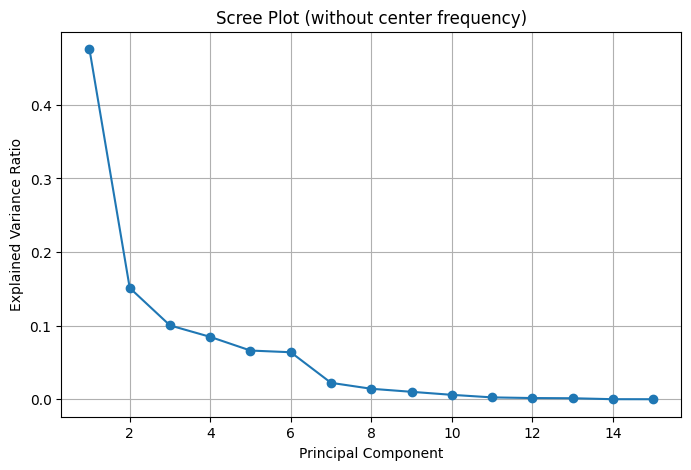

In [27]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (without center frequency)")
plt.grid(True)
plt.show()

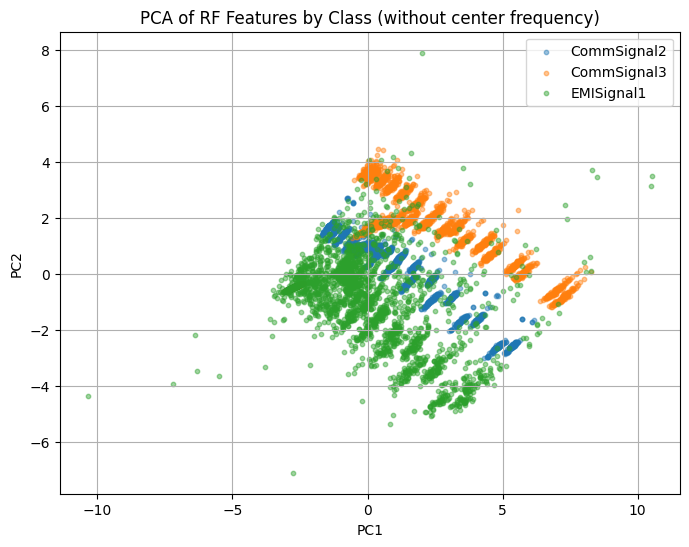

In [28]:
pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(8,6))
for cls in pca_df["base_class"].unique():
    idx = pca_df["base_class"] == cls
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        alpha=0.45,
        s=10,
        label=cls
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of RF Features by Class (without center frequency)")
plt.legend()
plt.grid(True)
plt.show()

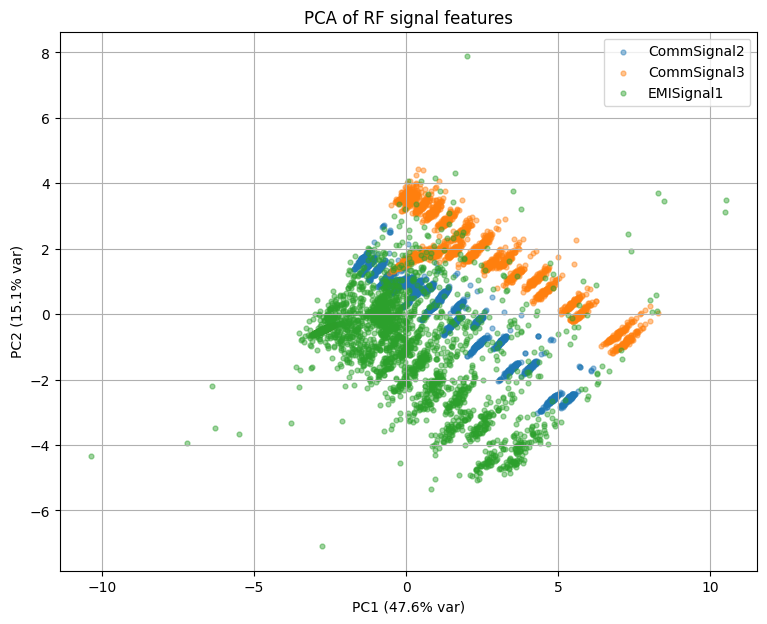

In [51]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(9, 7))
for cls in pca_df["base_class"].unique():
    idx = pca_df["base_class"] == cls
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        s=12,
        alpha=0.45,
        label=cls
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
plt.title("PCA of RF signal features")
plt.legend()
plt.grid(True)
plt.show()

The PCA projection reveals partial separation but also substantial overlap, indicating that the class structure is not fully linearly separable in the first two principal directions. At the same time, the classes exhibit distinct banded substructures, suggesting latent within-class regimes or repeated waveform configurations.

* Is PC1 mostly power/amplitude variation?
* Is PC2 mostly spectral structure?
* Is one PC mostly phase variability?
* Do CommSignal2, CommSignal3, and EMISignal1 separate along those directions?

The first principal component is primarily associated with overall signal magnitude and variability, with the strongest loadings on peak amplitude, amplitude dispersion, in-phase and quadrature standard deviations, and RMS power. The second principal component is driven more by peak-to-average ratio and spectral complexity, as reflected by strong loadings on PAPR, spectral entropy, and spectral flatness. Thus, the dominant axes of variation separate overall energy/dispersion effects from waveform-shape and spectral-structure effects.

In [29]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_no_cf,
    columns=[f"PC{i+1}" for i in range(len(feature_cols_no_cf))]
)

print("Top absolute loadings for PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False))

print("\nTop absolute loadings for PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False))

print("\nSigned loadings for PC1 and PC2:")
print(loadings[["PC1", "PC2"]].sort_values("PC1", key=np.abs, ascending=False))

Top absolute loadings for PC1:
amp_max          0.354639
amp_std          0.344229
imag_std         0.334230
real_std         0.334011
rms_power        0.320677
amp_mean         0.318454
mag_skew         0.275157
spec_flatness    0.269365
papr             0.239895
phase_std        0.212879
spec_entropy     0.207758
mag_kurt         0.176466
imag_mean        0.039735
real_mean        0.028638
spec_centroid    0.019480
Name: PC1, dtype: float64

Top absolute loadings for PC2:
papr             0.433090
spec_entropy     0.395534
spec_flatness    0.392896
amp_mean         0.336355
rms_power        0.322911
mag_skew         0.302510
real_std         0.295431
imag_std         0.294855
phase_std        0.094465
mag_kurt         0.077341
spec_centroid    0.050777
real_mean        0.020067
imag_mean        0.017769
amp_std          0.013664
amp_max          0.009596
Name: PC2, dtype: float64

Signed loadings for PC1 and PC2:
                    PC1       PC2
amp_max        0.354639  0.009596
amp

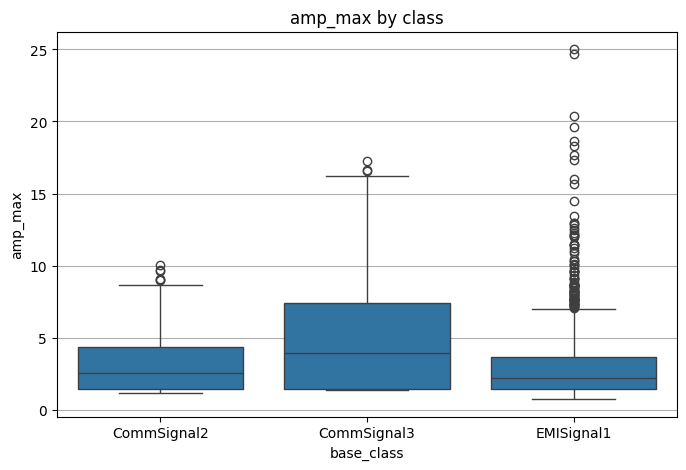

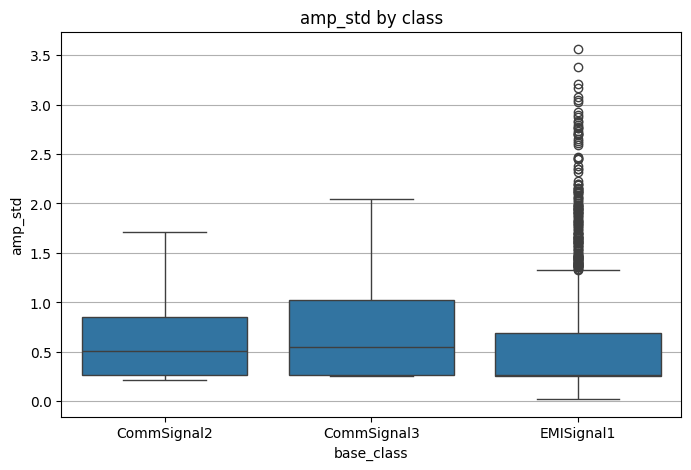

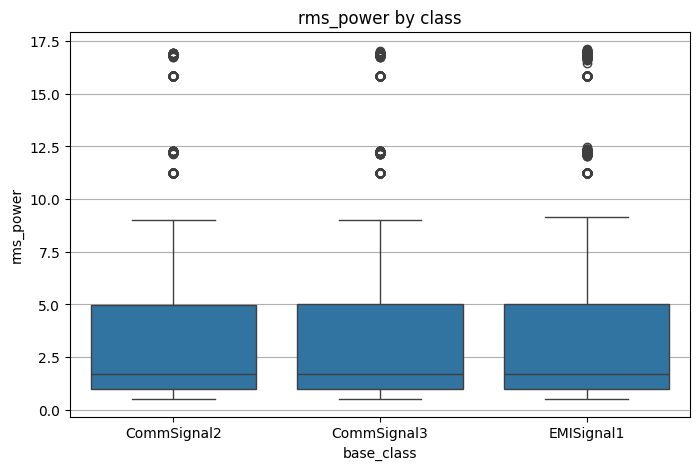

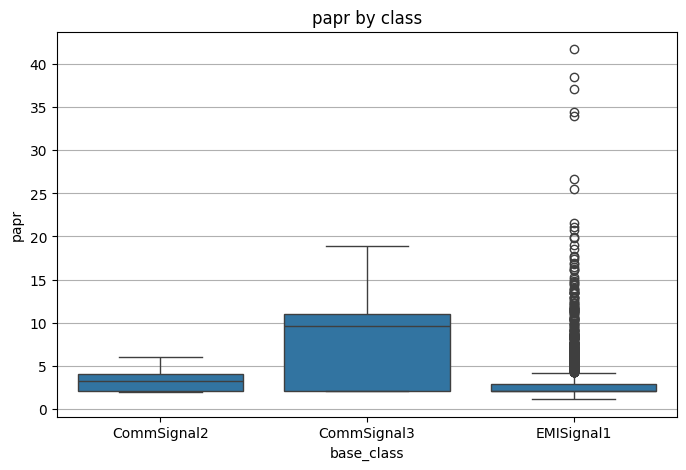

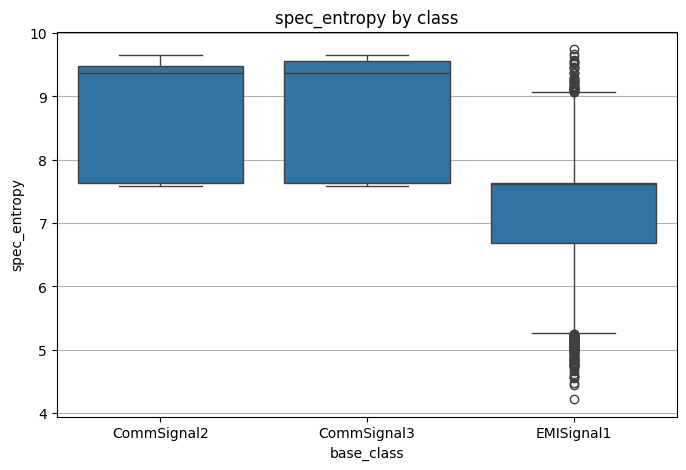

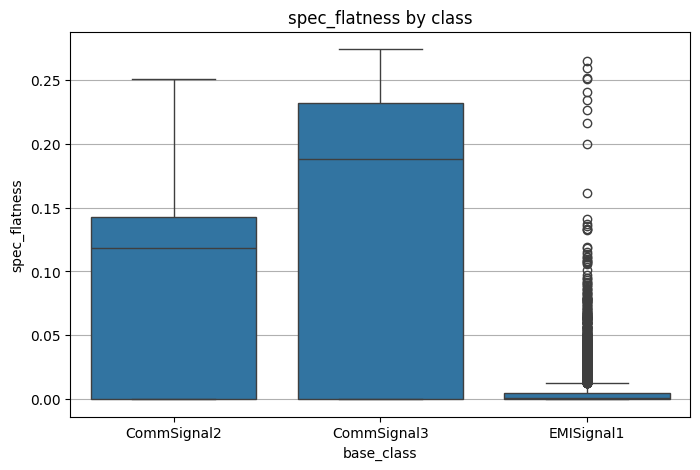

In [31]:
for feat in ["amp_max", "amp_std", "rms_power", "papr", "spec_entropy", "spec_flatness"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="base_class", y=feat)
    plt.title(f"{feat} by class")
    plt.grid(True, axis="y")
    plt.show()

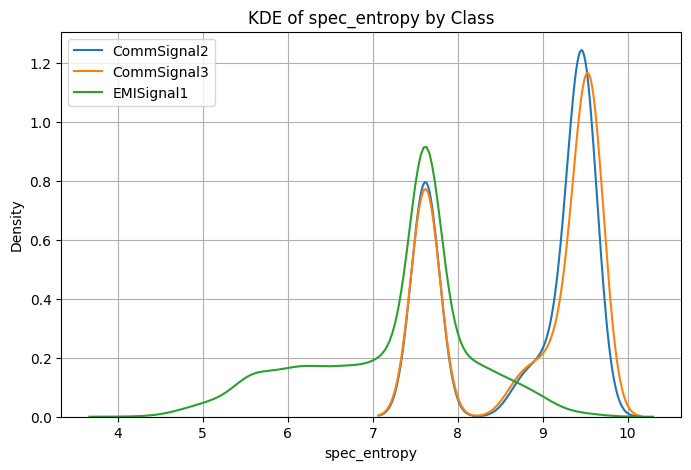

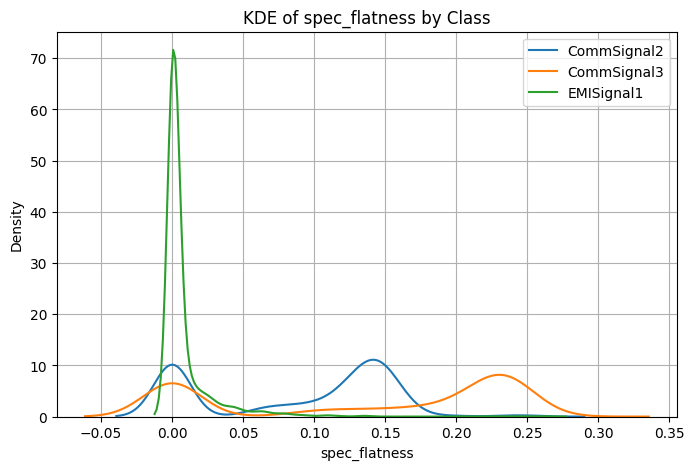

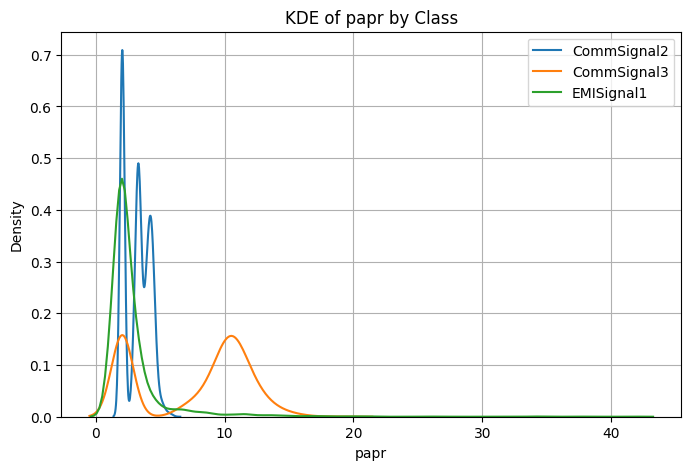

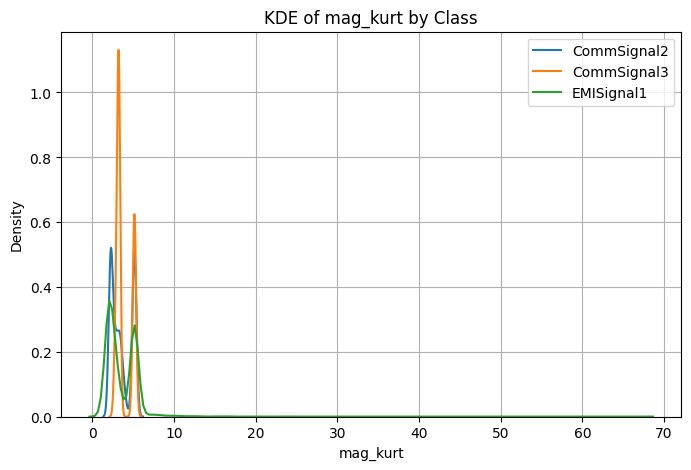

In [32]:
for feat in ["spec_entropy", "spec_flatness", "papr", "mag_kurt"]:
    plt.figure(figsize=(8,5))
    for cls in df["base_class"].unique():
        sns.kdeplot(
            data=df[df["base_class"] == cls],
            x=feat,
            label=cls,
            fill=False
        )
    plt.title(f"KDE of {feat} by Class")
    plt.grid(True)
    plt.legend()
    plt.show()

In [33]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

lda = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lda, X_cls, y_cls, cv=cv, scoring="accuracy")

print("LDA CV accuracy (without center_freq):")
print("mean =", scores.mean())
print("std  =", scores.std())
print("scores =", scores)

LDA CV accuracy (without center_freq):
mean = 0.7696969696969697
std  = 0.009034618090908237
scores = [0.78686869 0.76212121 0.76616162 0.76313131 0.77020202]


In [34]:
X_cls_cf = df[feature_cols_with_cf].copy().dropna()
y_cls_cf = df.loc[X_cls_cf.index, "base_class"]

scores_cf = cross_val_score(lda, X_cls_cf, y_cls_cf, cv=cv, scoring="accuracy")

print("LDA CV accuracy (with center_freq):")
print("mean =", scores_cf.mean())
print("std  =", scores_cf.std())
print("scores =", scores_cf)

LDA CV accuracy (with center_freq):
mean = 1.0
std  = 0.0
scores = [1. 1. 1. 1. 1.]


LDA

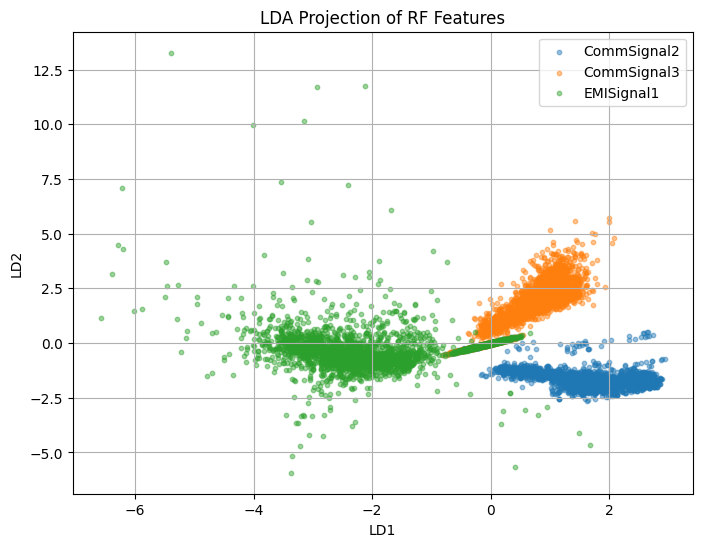

In [35]:
lda_fit = LinearDiscriminantAnalysis(n_components=2)
Z_lda = lda_fit.fit_transform(X_cls, y_cls)

lda_df = pd.DataFrame({
    "LD1": Z_lda[:, 0],
    "LD2": Z_lda[:, 1],
    "base_class": y_cls.values
})

plt.figure(figsize=(8,6))
for cls in lda_df["base_class"].unique():
    idx = lda_df["base_class"] == cls
    plt.scatter(
        lda_df.loc[idx, "LD1"],
        lda_df.loc[idx, "LD2"],
        alpha=0.45,
        s=10,
        label=cls
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of RF Features")
plt.legend()
plt.grid(True)
plt.show()

QDA

In [41]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

qda = QuadraticDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_qda = cross_val_score(qda, X_cls, y_cls, cv=cv, scoring="accuracy")
print("QDA CV accuracy (without center_freq):")
print("mean =", scores_qda.mean())
print("std  =", scores_qda.std())
print("scores =", scores_qda)

QDA CV accuracy (without center_freq):
mean = 0.775959595959596
std  = 0.00957520349588208
scores = [0.79393939 0.76868687 0.77020202 0.76919192 0.77777778]


d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help redu

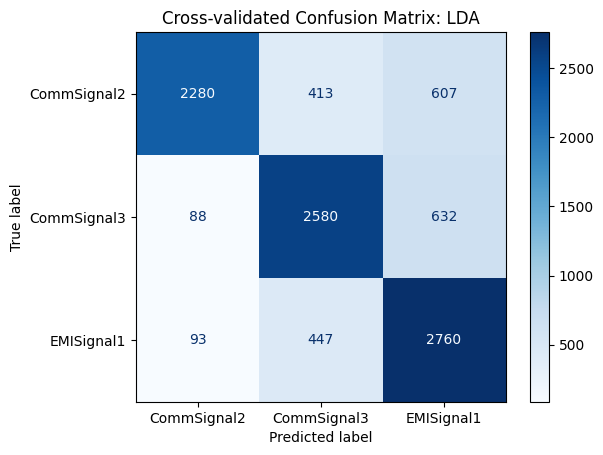

In [47]:
y_pred = cross_val_predict(lda, X_cls, y_cls, cv=cv)

cm = confusion_matrix(y_cls, y_pred, labels=sorted(y_cls.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_cls.unique()))
disp.plot(cmap="Blues")
plt.title("Cross-validated Confusion Matrix: LDA")
plt.show()

t-SNE

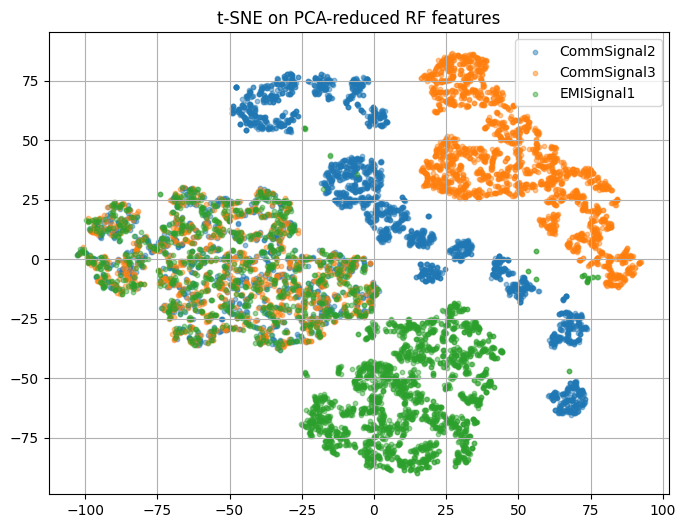

In [39]:
X_scaled = StandardScaler().fit_transform(df[feature_cols_no_cf])
pca_8 = PCA(n_components=8)
X_pca8 = pca_8.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
T = tsne.fit_transform(X_pca8)

tsne_df = pd.DataFrame({
    "TSNE1": T[:, 0],
    "TSNE2": T[:, 1],
    "base_class": df["base_class"].values
})

plt.figure(figsize=(8,6))
for cls in tsne_df["base_class"].unique():
    idx = tsne_df["base_class"] == cls
    plt.scatter(
        tsne_df.loc[idx, "TSNE1"],
        tsne_df.loc[idx, "TSNE2"],
        alpha=0.45,
        s=10,
        label=cls
    )
plt.title("t-SNE on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

UMAP

d:\Anaconda\envs\imitation_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


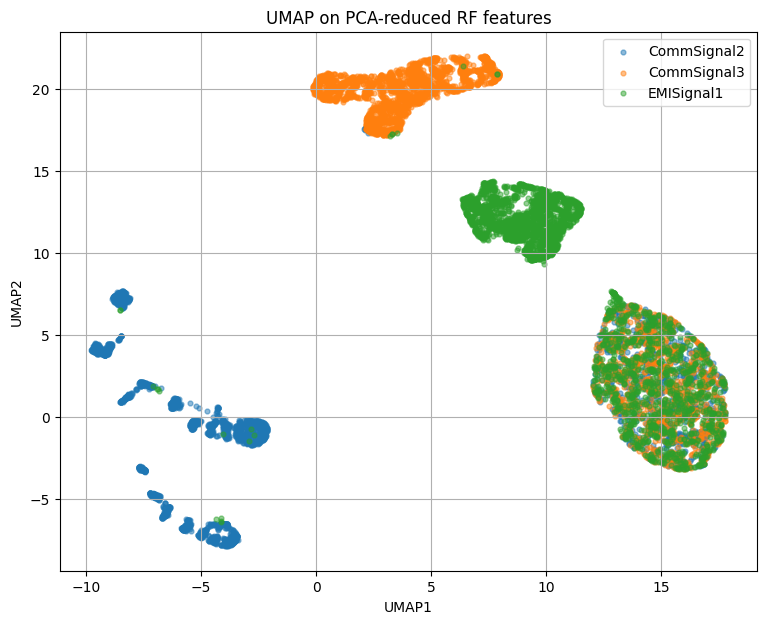

In [48]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"].copy()

# -----------------------------
# Standardize
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Optional PCA preprocessing
# UMAP often behaves better if
# you reduce a bit first
# -----------------------------
pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# UMAP
# -----------------------------
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42
)

U = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({
    "UMAP1": U[:, 0],
    "UMAP2": U[:, 1],
    "base_class": y.values
})

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 7))
for cls in umap_df["base_class"].unique():
    idx = umap_df["base_class"] == cls
    plt.scatter(
        umap_df.loc[idx, "UMAP1"],
        umap_df.loc[idx, "UMAP2"],
        s=12,
        alpha=0.5,
        label=cls
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

logreg = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_log = cross_val_score(logreg, X_cls, y_cls, cv=cv, scoring="accuracy")

print("Multinomial logistic CV accuracy:")
print("mean =", scores_log.mean())
print("std  =", scores_log.std())
print("scores =", scores_log)

d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

Multinomial logistic CV accuracy:
mean = 0.7624242424242424
std  = 0.0035511910770195635
scores = [0.76515152 0.76515152 0.76565657 0.75808081 0.75808081]


# Part B: Density and Setting Analysis

Q: Which features distinguish QPSK + CommSignal2 from QPSK + CommSignal3 or EMI mixtures? Are there density shifts that reflect mixture difficulty?

* KDE
* PCA Coordinates
* Feature Distribution Comparisons

# Part C: Predictive Modeling

## Q: Can multivariate features predict source/interference class or decoding success?
* Logistic Regression
* Ridge Regression
* Cross-Validation



In [53]:
results_summary = pd.DataFrame({
    "Model": [
        "LDA (no center_freq)",
        "QDA (no center_freq)",
        "Multinomial Logistic (no center_freq)",
        "LDA (with center_freq)"
    ],
    "Mean CV Accuracy": [
        0.7696969696969697,
        0.775959595959596,
        0.7624242424242424,
        1.0
    ],
    "Std CV Accuracy": [
        0.009034618090908237,
        0.00957520349588208,
        0.0035511910770195635,
        0.0
    ]
})

results_summary["Mean CV Accuracy"] = results_summary["Mean CV Accuracy"].round(4)
results_summary["Std CV Accuracy"] = results_summary["Std CV Accuracy"].round(4)

print(results_summary)

                                   Model  Mean CV Accuracy  Std CV Accuracy
0                   LDA (no center_freq)            0.7697           0.0090
1                   QDA (no center_freq)            0.7760           0.0096
2  Multinomial Logistic (no center_freq)            0.7624           0.0036
3                 LDA (with center_freq)            1.0000           0.0000


In [54]:
top_feats = ["spec_flatness", "spec_entropy", "papr", "amp_max"]

class_summary_mean = df.groupby("base_class")[top_feats].mean().round(4)
class_summary_std = df.groupby("base_class")[top_feats].std().round(4)

print("Classwise means:")
print(class_summary_mean)

print("\nClasswise standard deviations:")
print(class_summary_std)

Classwise means:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0870        8.7852  3.2329   3.1917
CommSignal3         0.1374        8.8123  7.7343   5.0307
EMISignal1          0.0083        7.2680  2.8413   2.8242

Classwise standard deviations:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0663        0.8431  0.9476   1.9951
CommSignal3         0.1033        0.8691  4.2552   3.7763
EMISignal1          0.0209        0.9327  2.5852   2.0336


### Results

Dataset is balanced across the three classes.

PCA:

PC1 mostly captures amplitude/power dispersion.

PC2 captures spectral complexity and peakiness.

KDE:

spec_flatness, spec_entropy, and papr separate classes strongly.

Classification:

LDA: 0.7697

QDA: 0.7760

multinomial logistic: 0.7624

with center_freq, LDA reaches 1.000

Confusion matrix:

CommSignal2 hardest to classify

EMISignal1 easiest

UMAP/t-SNE:

nonlinear structure and possible class subregimes

partial overlap remains between some CommSignal3 and EMISignal1 regions